Greyson Roy \
9\2\2026 \
Lab 2 - Energy Projectile Tracker

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Part A - Add Energy Tracking

In [3]:
def simulate_projectile_2d(v0, theta_deg, dt, g):
    theta_rad = np.deg2rad(theta_deg)
    vx = v0*np.cos(theta_rad)
    vy = v0*np.sin(theta_rad)
    x = 0
    y = 0
    t = 0
    KE = 0.5*(vx**2+vy**2)
    PE = g*y
    E_total = KE + PE
    state = {'t':[t], 'x':[x], 'y':[y], 'Vx':[vx], 'Vy':[vy], 'KE':[KE], 'PE':[PE], 'E':[E_total]}
    while y>=0:
        vx_old = vx
        vy_old = vy
        vx += 0
        vy += -g*dt
        x += vx_old*dt
        y += vy_old*dt
        t += dt
        KE = 0.5*(vx**2+vy**2)
        PE = g*y
        E_total = KE + PE

        state['t'].append(t)
        state['x'].append(x)
        state['y'].append(y)
        state['Vx'].append(vx)
        state['Vy'].append(vy)
        state['KE'].append(KE)
        state['PE'].append(PE)
        state['E'].append(E_total)
    return state

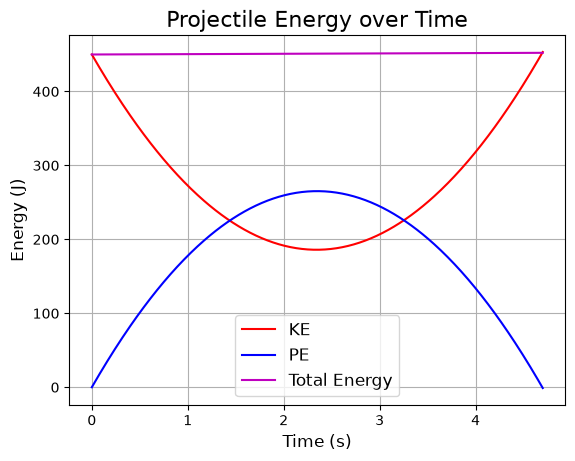

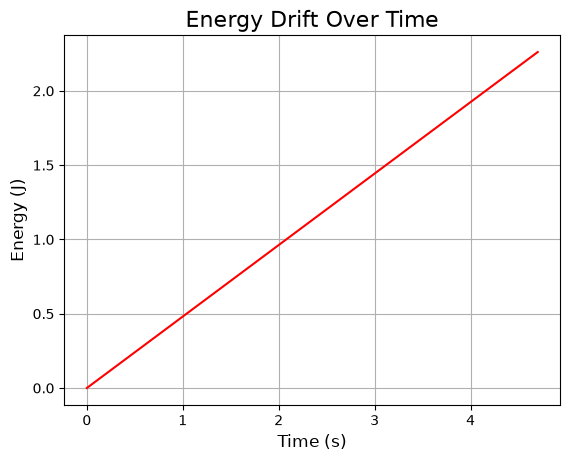

The max energy drift over the flight was 0.5000532011290287 percent of the initial enery


In [33]:
state_list = simulate_projectile_2d(30, 50, 0.01, 9.81)
t_list = state_list['t']
KE_list = state_list['KE']
PE_list = state_list['PE']
E_list = state_list['E']
E_drift = [energy - E_list[0] for energy in E_list]

plt.plot(t_list, KE_list, 'r-', label='KE')
plt.plot(t_list, PE_list, 'b-', label='PE')
plt.plot(t_list, E_list, 'm-', label='Total Energy')
plt.legend(fontsize=12)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Energy (J)', fontsize=12)
plt.title('Projectile Energy over Time', fontsize=16)
plt.grid(True)
plt.show()

plt.plot(t_list, E_drift, 'r-')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Energy (J)', fontsize=12)
plt.title('Energy Drift Over Time', fontsize=16)
plt.grid(True)
plt.show()

print(f'The max energy drift over the flight was {100*max(E_drift)/E_list[-1]} percent of the initial enery')

1. The modified function is above.
2. The function as requested was run above.
3. The plots as requested are above.
4. The maximum energy drift over the flight was 0.5 % of the initial energy.

We can see from the plots above that with a standard Euler simulation, the enery of the projectile grows at a steady rate during the duration of its flight. That is, the drift is steady and does not accelerate. Roughly 0.5% of the initial energy is gained by the time it lands.

Part B - Euler vs. Euler-Cromer

In [5]:
def simulate(method, v0, theta_deg, g, dt):
    """Simulates projectile with energy tracking,
    method is 'euler' or 'euler-cromer'
    """
    m = 1.0
    theta_rad = np.deg2rad(theta_deg)
    t = 0
    x, y = 0.0, 0.0
    vx, vy = v0*np.cos(theta_rad), v0*np.sin(theta_rad)
    KE, PE = 0.5*(vx**2+vy**2), m*g*y
    E_total = KE + PE

    state = {'t':[t], 'x':[x], 'y':[y], 'Vx':[vx], 'Vy':[vy], 'KE':[KE], 'PE':[PE], 'E':[E_total]}

    ax = 0.0
    ay = -g

    while y>=0:

        if method == 'euler':
            x += vx*dt
            y += vy*dt
            vx += ax*dt
            vy += ay*dt
        elif method == 'euler-cromer':
            vx += ax*dt
            vy += ay*dt
            x += vx*dt
            y += vy*dt

        t += dt
        KE, PE = 0.5*(vx**2+vy**2), m*g*y
        E_total = KE + PE

        state['t'].append(t)
        state['x'].append(x)
        state['y'].append(y)
        state['Vx'].append(vx)
        state['Vy'].append(vy)
        state['KE'].append(KE)
        state['PE'].append(PE)
        state['E'].append(E_total)

    return state

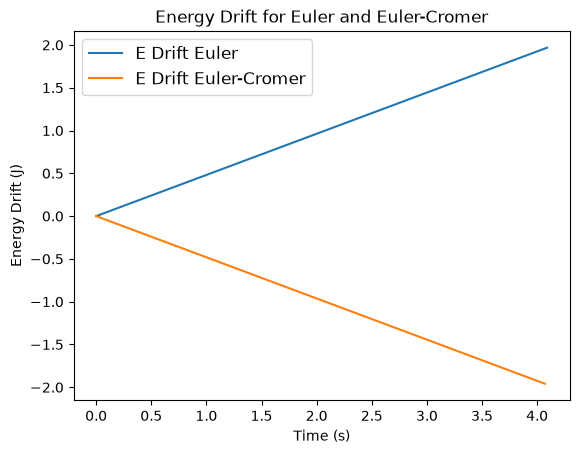

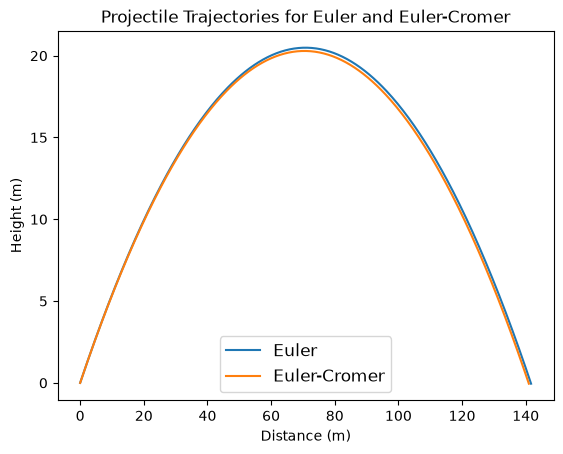

The difference between the range of the Euler and Euler-Cromer simulations is 0.6928 m.


In [6]:
euler_state = simulate('euler', 40, 30, 9.81, 0.01)
e_cromer_state = simulate('euler-cromer', 40, 30, 9.81, 0.01)

E_drift_euler = [energy - euler_state['E'][0] for energy in euler_state['E']]
E_drift_e_cromer = [energy - e_cromer_state['E'][0] for energy in e_cromer_state['E']]
t_euler = euler_state['t']
t_e_cromer = e_cromer_state['t']

plt.plot(t_euler, E_drift_euler, label='E Drift Euler')
plt.plot(t_e_cromer, E_drift_e_cromer, label='E Drift Euler-Cromer')
plt.legend(fontsize=12)
plt.xlabel('Time (s)')
plt.ylabel('Energy Drift (J)')
plt.title('Energy Drift for Euler and Euler-Cromer')
plt.show()

plt.plot(euler_state['x'], euler_state['y'], label='Euler')
plt.plot(e_cromer_state['x'], e_cromer_state['y'], label='Euler-Cromer')
plt.legend(fontsize=12)
plt.xlabel('Distance (m)')
plt.ylabel('Height (m)')
plt.title('Projectile Trajectories for Euler and Euler-Cromer')
plt.show()

dist_diff = euler_state['x'][-1] - e_cromer_state['x'][-1]
print(f'The difference between the range of the Euler and Euler-Cromer simulations is {dist_diff:.4f} m.')

1. The simulate function is defined above.
2. Runs for both methods are completed above.
3. The energy drift plot as requested is above.
4. The plot with the Euler and Euler-Cromer trajectories is above. We can see that they are different and the difference in landing range between them is 0.6928 m.

It is strange to think that such small difference in order changes the energy behaviour as it does. 

Part C - Convergence Study

1.0095828621290337
0.9937521729966096


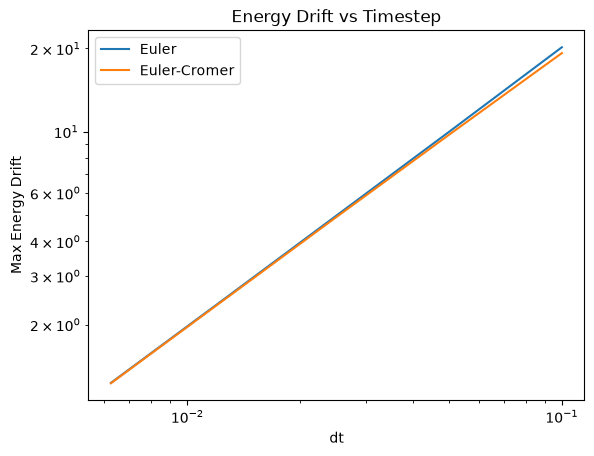

In [36]:
Euler_Error = []
time_step_list = []

for n in range(5):
    time_step = 0.1/(2**n)
    Energy = simulate('euler', 40, 30, 9.81, time_step)['E']
    energy_drift = [abs(energy-Energy[0]) for energy in Energy]
    time_step_list.append(time_step)
    Euler_Error.append(max(energy_drift))

Cromer_Error = []

for n in time_step_list:
    time_step = n
    Energy = simulate('euler-cromer', 40, 30, 9.81, time_step)['E']
    energy_drift = [abs(energy-Energy[0]) for energy in Energy]
    Cromer_Error.append(max(energy_drift))

Euler_Slope = np.polyfit(np.log(time_step_list), np.log(Euler_Error), 1)[0]
Cromer_Slope = np.polyfit(np.log(time_step_list), np.log(Cromer_Error), 1)[0]

plt.loglog(time_step_list, Euler_Error, label='Euler')
plt.loglog(time_step_list, Cromer_Error, label='Euler-Cromer')
plt.legend()
plt.xlabel('dt')
plt.ylabel('Max Energy Drift')
plt.title('Energy Drift vs Timestep')

print(Euler_Slope)
print(Cromer_Slope)

1. The simulation is run for each dt above.
2. The max energy drift for each dt is recorded in a list above.
3. The loglog plot for the Euler method is above, and the slope was fitted to 1.010.
4. The loglog plot for the Euler-Cromer method is above, and the slope was fitted to 0.994.
5. With the Euler method, its slope being 1.010, halving dt a little more than halves the error. With the Euler-Cromer method, its slope being 0.994, halving dt a little under halves the error.

1. The measured order of p for standard Euler is roughly 1, this agrees with the lesson as it claims that the Euler method is a first order operator.
2. The Euler-Cromer method is also roughly of order 1, and from the plot we can see that the energy drift is consistently lower than the Euler method.
3. If I needed energy to be conserved within 0.01%, I would use the Euler method with dt = 0.00015, this is because, from part A, a dt of 0.01 yields an error of 0.5%, and since it is first order, dividing dt by 64 should roughly divide the error by 64 to less than 0.01% error.

Bonus - Drag and Physical Energy Loss

In [23]:
def simulate_drag(method, v0, theta_deg, g, b_over_m, dt):
    """Simulates projectile with energy tracking,
    method is 'euler' or 'euler-cromer'
    """
    m = 1.0
    theta_rad = np.deg2rad(theta_deg)
    t = 0
    x, y = 0.0, 0.0
    vx, vy = v0*np.cos(theta_rad), v0*np.sin(theta_rad)
    speed = np.sqrt(vx**2+vy**2)
    KE, PE = 0.5*(vx**2+vy**2), m*g*y
    E_total = KE + PE
    f_x = m*b_over_m*speed*vx
    f_y = m*b_over_m*speed*vy

    state = {'t':[t], 'x':[x], 'y':[y], 'Vx':[vx], 'Vy':[vy], 'Speed':[speed],  'KE':[KE], 'PE':[PE], 'E':[E_total], 'F_x':[f_x], 'F_y':[f_y]}

    ax = 0.0
    ay = -g

    while y>=0:
        if method == 'euler':
            speed = np.sqrt(vx**2+vy**2)
            x += vx*dt
            y += vy*dt
            vx += -b_over_m*speed*vx*dt
            vy += (-g-b_over_m*speed*vy)*dt
        elif method == 'euler-cromer':
            vx += -b_over_m*speed*vx*dt
            vy += (-g-b_over_m*speed*vy)*dt
            speed = np.sqrt(vx**2+vy**2)
            x += vx*dt
            y += vy*dt

        t += dt
        KE, PE = 0.5*(vx**2+vy**2), m*g*y
        E_total = KE + PE
        f_x = m*b_over_m*speed*vx
        f_y = m*b_over_m*speed*vy

        state['t'].append(t)
        state['x'].append(x)
        state['y'].append(y)
        state['Vx'].append(vx)
        state['Vy'].append(vy)
        state['Speed'].append(speed)
        state['KE'].append(KE)
        state['PE'].append(PE)
        state['E'].append(E_total)
        state['F_x'].append(f_x)
        state['F_y'].append(f_y)

    return state

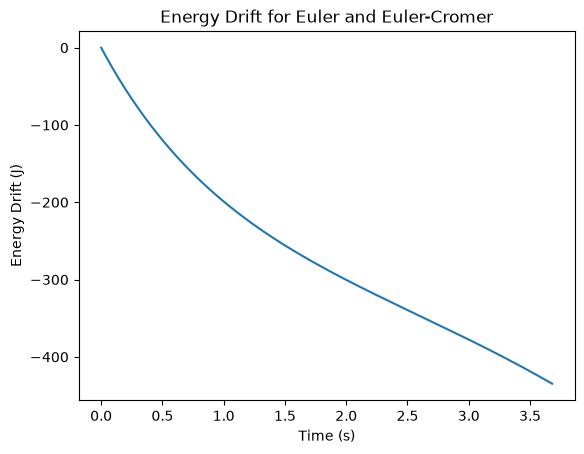

The total mechanical energy lost during the flight is 434.74053813805534
The energy lost to drag is 432.5959031495397 J
The difference between the energy drift and energy lost to drag is 0.004933137815260715 J


In [ ]:
e_cromer_state = simulate_drag('euler-cromer', 40, 30, 9.81, 0.0046, 0.01)

E_drift_e_cromer = [energy - e_cromer_state['E'][0] for energy in e_cromer_state['E']]
t_e_cromer = e_cromer_state['t']

plt.plot(t_e_cromer, E_drift_e_cromer)
plt.xlabel('Time (s)')
plt.ylabel('Energy Drift (J)')
plt.title('Energy Drift for Euler and Euler-Cromer')
plt.show()

Drag_Loss = -sum([
    e_cromer_state['F_x'][n]*(e_cromer_state['x'][n+1]-e_cromer_state['x'][n]) +
    e_cromer_state['F_y'][n]*(e_cromer_state['y'][n+1]-e_cromer_state['y'][n]) 
    for n in range(len(e_cromer_state['x'])-1)])

print(f'The total mechanical energy lost during the flight is {-E_drift_e_cromer[-1]}')
print(f'The energy lost to drag is {-Drag_Loss} J')
print(f'The difference between the energy drift and energy lost to drag is {E_drift_e_cromer[-1]-Drag_Loss} J')

1. From the plot we can see that the energy drift decrease monotonically with time
2. The total mechanical energy lost over the flight is 434.74 J, and the total energy lost to drag is 432.60 J.
3. These differ by less than 1 percent, so we can conclude that they agree to within a small degree of error.